In [ ]:
"""
LDA 

assumptions - 
Gaussian distribution of features within each class
Equal covariance matrices across classes
Independent observations
Different class means

"""

In [93]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

np.random.seed(42)
n = 600  # samples per class

# Shared covariance. LDA assumption
"""
         BP    Chol   BMI   Age
    BP  [10,    3,     1,    2  ]
    Ch  [ 3,   15,     2,    3  ]
    BMI [ 1,    2,     4,    1  ]
    Age [ 2,    3,     1,   20  ]
"""

cov = [[10, 3,  1,  2],
       [3,  15, 2,  3],
       [1,  2,  4,  1],
       [2,  3,  1,  20]]

# means of each predictors' classes
mean_low    = [110, 170, 22, 35]
mean_medium = [130, 200, 27, 50]
mean_high   = [155, 235, 32, 62]

X_low = np.random.multivariate_normal(mean_low, cov, n)
X_medium = np.random.multivariate_normal(mean_medium, cov, n)
X_high = np.random.multivariate_normal(mean_high, cov, n)

# vertical stack
X_clean = np.vstack([X_low, X_medium, X_high])
y = np.array([0] * n + [1] * n + [2] * n)

# add Gaussian noise to features
# Noise std is scaled per feature to create ~15-20% class overlap
noise_std = [8, 18, 3.5, 12]   # one value per feature
noise = np.random.normal(0, noise_std, X_clean.shape)
X_final = X_clean + noise

feature_names = ['blood_pressure', 'cholesterol', 'bmi', 'age']

df = pd.DataFrame(X_final, columns=feature_names)
df['risk_level'] = y
df['risk_label'] = df['risk_level'].map({0: 'Low', 1: 'Medium', 2: 'High'})

print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (1800, 6)
   blood_pressure  cholesterol        bmi        age  risk_level risk_label
0      111.857018   168.470477  27.391128  23.018321           0        Low
1      100.170394   170.581768  24.482607  53.998909           0        Low
2       99.870157   194.095006  29.903155  31.301529           0        Low
3       92.625954   158.734036  19.904429  45.061947           0        Low
4      104.649914   202.636394  16.106735  17.703286           0        Low


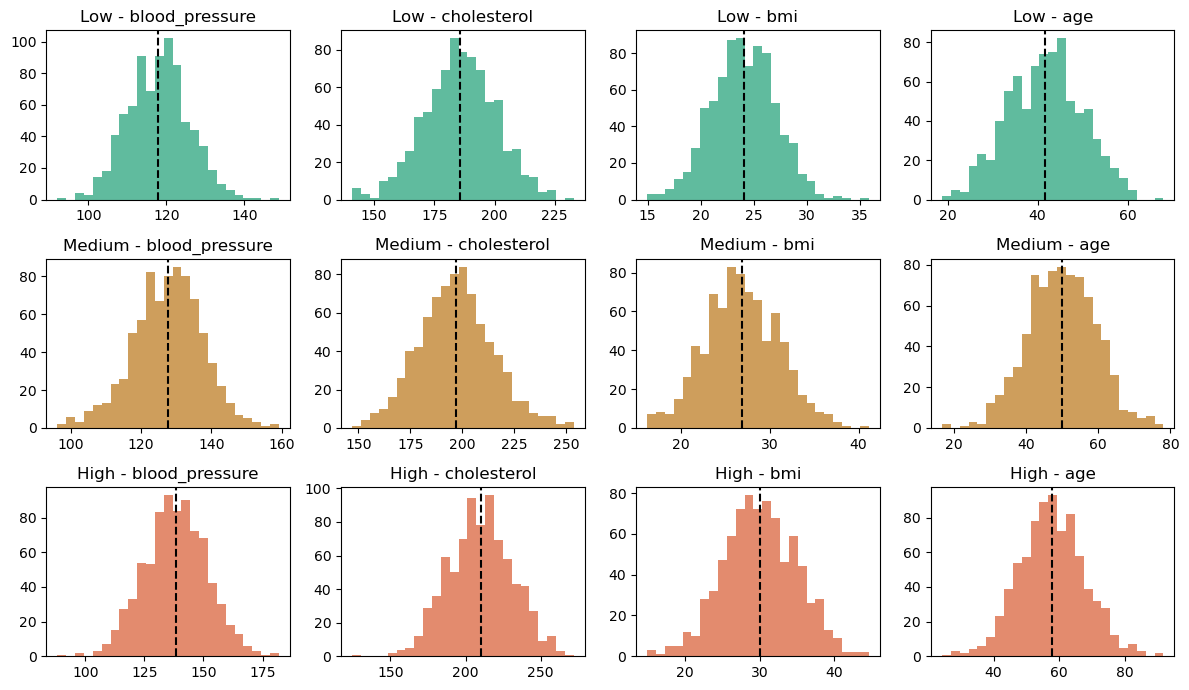

In [95]:
import matplotlib.pyplot as plt

class_labels = {0: 'Low', 1: 'Medium', 2: 'High'}
colors       = ['#1D9E75', '#BA7517', '#D85A30']

# Normality — a normal distribution looks like a bell curve
fig, axes = plt.subplots(3, 4, figsize=(12,7))

for cls in [0,1,2]:
    for j, feat in enumerate(feature_names):
        ax = axes[cls, j]
        data = X_train[y_train == cls, j]
        ax.hist(data, bins=25, color=colors[cls], alpha=0.7)
        ax.axvline(data.mean(), linestyle='--', color='black')
        ax.set_title(f"{class_labels[cls]} - {feat}")
plt.tight_layout()
plt.show()

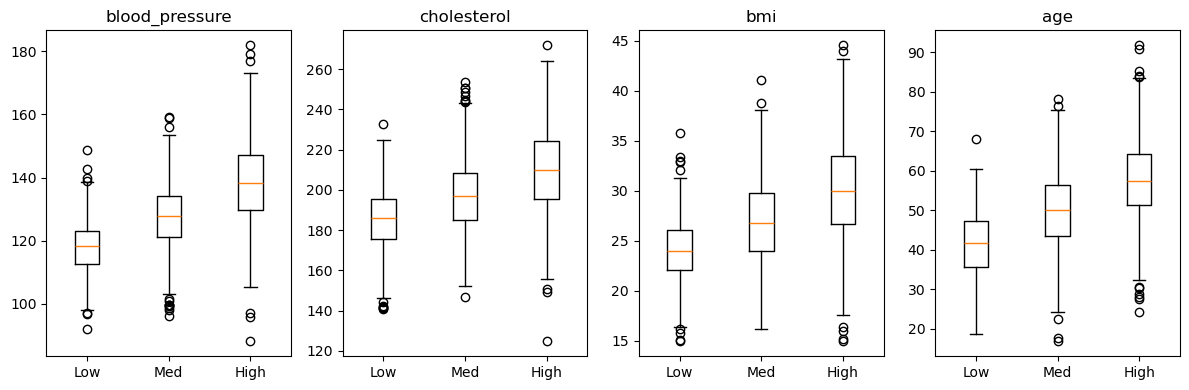

In [97]:
# equal spread — std per class per feature
# LDA needs similar spread across classes
fig, axes = plt.subplots(1,4, figsize=(12,4))
for j, feat in enumerate(feature_names):
    data = [
        X_train[y_train == 0, j],
        X_train[y_train == 1, j],
        X_train[y_train == 2, j]
    ]

    axes[j].boxplot(data)
    axes[j].set_title(feat)
    axes[j].set_xticklabels(['Low','Med','High'])
plt.tight_layout()
plt.show()

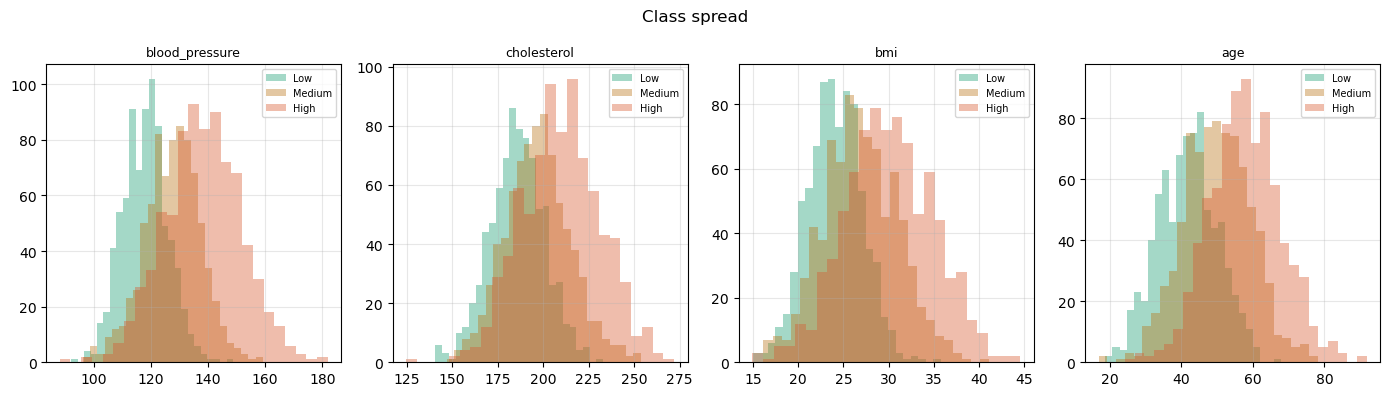

In [99]:
# class separation
# LDA only works if classes have different means
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
fig.suptitle("Class spread", fontsize=12)

for j, feat in enumerate(feature_names):
    for cls in [0,1,2]:
        data = X_train[y_train == cls, j]
        axes[j].hist(data,
                     bins=25,
                     alpha=0.4,
                     color=colors[cls],
                     label=class_labels[cls])

    axes[j].set_title(feat, fontsize=9)
    axes[j].legend(fontsize=7)
    axes[j].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [100]:
# stratify tells to maintain same ratio of classes in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

lda = LinearDiscriminantAnalysis(store_covariance=True)
lda.fit(X_train_sc, y_train)

y_pred = lda.predict(X_test_sc)
y_prob = lda.predict_proba(X_test_sc)

print(f"LDA Accuracy: {accuracy_score(y_test, y_pred):.4f}")

LDA Accuracy: 0.9417


In [101]:
coef_df = pd.DataFrame(
    lda.scalings_,
    index=feature_names,
    columns=[f'LD{i+1}' for i in range(lda.scalings_.shape[1])]
).round(4)

print("Linear discriminant coefficients:")
print(coef_df)
print(f"\nExplained variance ratio: {lda.explained_variance_ratio_.round(4)}")

# estimated covariance matrix and means
print('\nCovariance matrix\n',lda.covariance_)

# each predictor and its mean of each class
print('\nClass means\n',lda.means_)

Linear discriminant coefficients:
                   LD1     LD2
blood_pressure -1.6469  0.7910
cholesterol    -0.8763  0.2089
bmi            -0.4161 -0.0863
age            -0.4127 -1.2451

Explained variance ratio: [9.991e-01 9.000e-04]

Covariance matrix
 [[ 0.18669524  0.00878691  0.01581041  0.00554562]
 [ 0.00878691  0.31862854  0.0171983  -0.01026615]
 [ 0.01581041  0.0171983   0.49627217  0.01804189]
 [ 0.00554562 -0.01026615  0.01804189  0.55804668]]

Class means
 [[-1.05911681 -0.97238536 -0.84411112 -0.83012412]
 [-0.08579582 -0.07318842 -0.04826247  0.03283118]
 [ 1.14491264  1.04557379  0.8923736   0.79729294]]


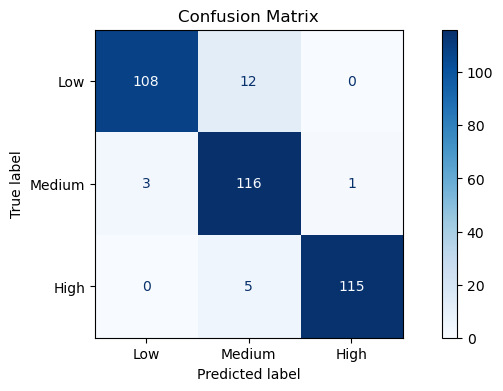

In [103]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(10,4))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=['Low','Medium','High'],
    cmap='Blues',
    ax=ax
)

ax.set_title("Confusion Matrix")
plt.show()

In [ ]:
"""
QDA

assumptions - 
Gaussian distribution of features within each class
Different covariance matrices across classes
Independent observations
Different class means

"""

In [104]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

np.random.seed(42)
n = 600

# class means
mean_low    = [118, 185, 24, 42]
mean_medium = [128, 198, 27, 50]
mean_high   = [138, 211, 30, 58]

# each class now has its own covariance matrix
# Low risk: tight cluster, low variance, weak correlations
# (healthy patients tend to cluster tightly)
cov_low = [[6,  1,   0.5, 1 ],
           [1,  8,   1,   1 ],
           [0.5,1,   2,   0.5],
           [1,  1,   0.5, 10]]

# Medium risk: moderate spread, moderate correlations
# (mixed patients, more variability)
cov_medium = [[15,  6,   2,  4 ],
              [6,   25,  3,  5 ],
              [2,   3,   6,  2 ],
              [4,   5,   2,  30]]

# High risk: wide spread, strong correlations between features
# (sick patients show compounding risk factors together)
cov_high = [[25,  12,  4,  8 ],
            [12,  40,  6,  10],
            [4,   6,   10, 4 ],
            [8,   10,  4,  50]]

X_low = np.random.multivariate_normal(mean_low, cov_low, n)
X_medium = np.random.multivariate_normal(mean_medium, cov_medium, n)
X_high = np.random.multivariate_normal(mean_high, cov_high, n)

X_clean = np.vstack([X_low, X_medium, X_high])
y = np.array([0]*n + [1]*n + [2]*n)

# moderate Gaussian noise
noise_std = [4, 8, 1.5, 6]
noise     = np.random.normal(0, noise_std, X_clean.shape)
X_final   = X_clean + noise

feature_names = ['blood_pressure', 'cholesterol', 'bmi', 'age']

df = pd.DataFrame(X_final, columns=feature_names)
df['risk_level'] = y
df['risk_label']  = df['risk_level'].map({0: 'Low', 1: 'Medium', 2: 'High'})

print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (1800, 6)
   blood_pressure  cholesterol        bmi        age  risk_level risk_label
0      119.292617   183.708260  27.037845  35.453925           0        Low
1      114.482067   184.680203  25.520718  51.381489           0        Low
2      112.699858   196.604629  27.265228  40.466392           0        Low
3      107.740154   178.406474  22.473959  47.961406           0        Low
4      114.890201   200.571400  20.893041  34.333898           0        Low


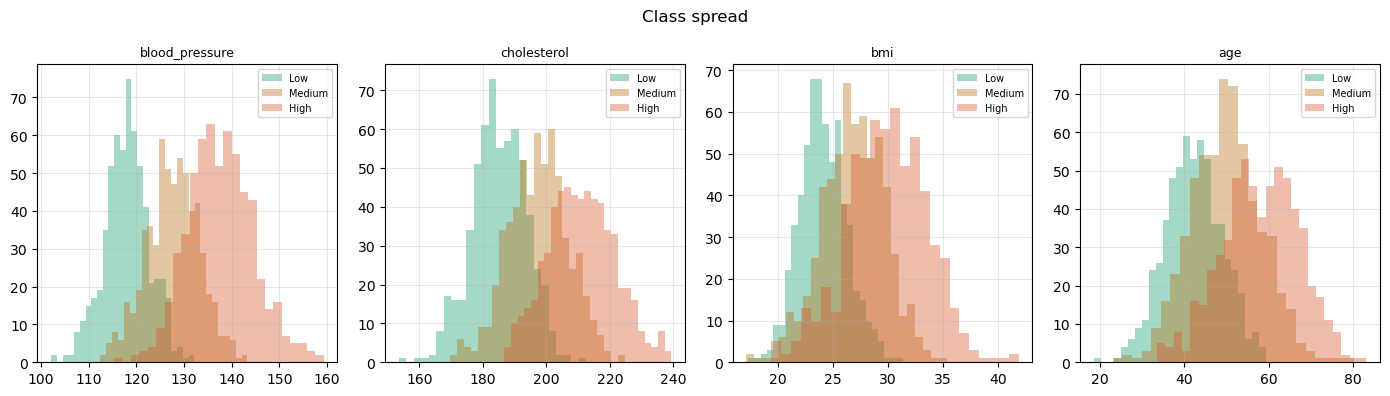

In [105]:
colors      = ['#1D9E75', '#BA7517', '#D85A30']
class_labels = {0: 'Low', 1: 'Medium', 2: 'High'}

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
fig.suptitle("Class spread", fontsize=12)

for j, feat in enumerate(feature_names):
    for cls in [0, 1, 2]:
        data = X_final[y == cls, j]
        axes[j].hist(data, 
                     bins=25, 
                     alpha=0.4,
                     color=colors[cls],
                     label=class_labels[cls])
    axes[j].set_title(feat, fontsize=9)
    axes[j].legend(fontsize=7)
    axes[j].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [106]:
# the class spread - Low is tight, High is wide

In [107]:
# std per class should be different
# Low should be smallest, High largest
print("Std per class per feature")
print("-" * 60)
print(f"  {'feature':20s} | {'Low':>8} | {'Medium':>8} | {'High':>8}")
print("-" * 60)
for j, feat in enumerate(feature_names):
    stds = [X_final[y == cls, j].std() for cls in [0, 1, 2]]
    print(f"  {feat:20s} | {stds[0]:8.2f} | {stds[1]:8.2f} | {stds[2]:8.2f}")

Std per class per feature
------------------------------------------------------------
  feature              |      Low |   Medium |     High
------------------------------------------------------------
  blood_pressure       |     4.70 |     5.53 |     6.79
  cholesterol          |     8.42 |     9.37 |    10.49
  bmi                  |     2.14 |     2.82 |     3.63
  age                  |     6.71 |     8.29 |     8.98


In [108]:
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, random_state=42, stratify=y
)

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("Train shape:", X_train_sc.shape)
print("Test shape :", X_test_sc.shape)

qda = QuadraticDiscriminantAnalysis(store_covariance=True)
qda.fit(X_train_sc, y_train)

y_pred = qda.predict(X_test_sc)
y_prob = qda.predict_proba(X_test_sc)

print(f"\nQDA Accuracy: {accuracy_score(y_test, y_pred):.4f}")

Train shape: (1440, 4)
Test shape : (360, 4)

QDA Accuracy: 0.8500


In [109]:
# per-class covariance matrices
for i, cls in enumerate([0, 1, 2]):
    print(f"Covariance matrix — {class_labels[cls]} risk:")
    cov_df = pd.DataFrame(
        qda.covariance_[i],
        index=feature_names,
        columns=feature_names
    ).round(3)
    print(cov_df)
    print()

Covariance matrix — Low risk:
                blood_pressure  cholesterol    bmi    age
blood_pressure           0.228       -0.001  0.012  0.042
cholesterol             -0.001        0.337  0.027 -0.014
bmi                      0.012        0.027  0.314  0.014
age                      0.042       -0.014  0.014  0.417

Covariance matrix — Medium risk:
                blood_pressure  cholesterol    bmi    age
blood_pressure           0.320        0.073  0.064  0.040
cholesterol              0.073        0.454  0.066 -0.008
bmi                      0.064        0.066  0.582  0.073
age                      0.040       -0.008  0.073  0.631

Covariance matrix — High risk:
                blood_pressure  cholesterol    bmi    age
blood_pressure           0.464        0.096  0.135  0.052
cholesterol              0.096        0.537  0.123  0.080
bmi                      0.135        0.123  0.886  0.145
age                      0.052        0.080  0.145  0.751



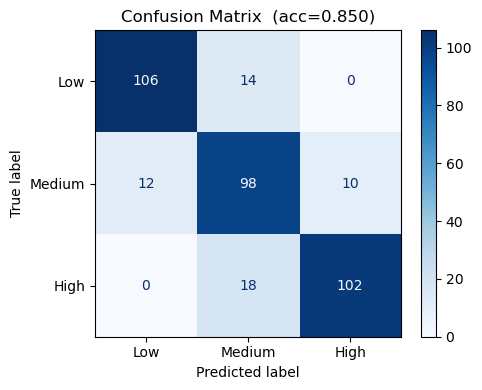

In [110]:
fig, ax = plt.subplots(figsize=(5, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Low', 'Medium', 'High'],
    cmap='Blues', ax=ax
)
ax.set_title(f"Confusion Matrix  (acc={accuracy_score(y_test, y_pred):.3f})")

plt.tight_layout()
plt.show()

In [111]:
"""
Naive Bayes

assumptions -
Features are conditionally independent given the class
Class prior probabilities exist
Feature likelihoods can be estimated for each class (e.g., Gaussian, multinomial, Bernoulli depending on variant)
Observations are independent

"""

'\nNaive Bayes\n\nassumptions -\nFeatures are conditionally independent given the class\nClass prior probabilities exist\nFeature likelihoods can be estimated for each class (e.g., Gaussian, multinomial, Bernoulli depending on variant)\nObservations are independent\n\n'

In [112]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

In [113]:
# GNB assumes features are INDEPENDENT within each class
# so we generate each feature separately — no multivariate normal
# no covariance matrix at all

np.random.seed(42)
n = 1000

# each feature generated independently per class
# Low risk
bp_low   = np.random.normal(118, 8,  n)
ch_low   = np.random.normal(185, 15, n)
bmi_low  = np.random.normal(24,  3,  n)
age_low  = np.random.normal(42,  8,  n)

# Medium risk
bp_med   = np.random.normal(128, 10, n)
ch_med   = np.random.normal(198, 18, n)
bmi_med  = np.random.normal(27,  4,  n)
age_med  = np.random.normal(50,  9,  n)

# High risk
bp_high  = np.random.normal(138, 13, n)
ch_high  = np.random.normal(211, 22, n)
bmi_high = np.random.normal(30,  5,  n)
age_high = np.random.normal(58,  10, n)

# stack into arrays
X_low    = np.column_stack([bp_low,  ch_low,  bmi_low,  age_low])
X_medium = np.column_stack([bp_med,  ch_med,  bmi_med,  age_med])
X_high   = np.column_stack([bp_high, ch_high, bmi_high, age_high])

X_final  = np.vstack([X_low, X_medium, X_high])
y        = np.array([0]*n + [1]*n + [2]*n)

feature_names = ['blood_pressure', 'cholesterol', 'bmi', 'age']
class_labels  = {0: 'Low', 1: 'Medium', 2: 'High'}
colors        = ['#1D9E75', '#BA7517', '#D85A30']

df = pd.DataFrame(X_final, columns=feature_names)
df['risk_level'] = y
df['risk_label']  = df['risk_level'].map({0: 'Low', 1: 'Medium', 2: 'High'})

print(df.head())

   blood_pressure  cholesterol        bmi        age  risk_level risk_label
0      121.973713   205.990332  21.974465  26.737540           0        Low
1      116.893886   198.869505  23.566444  35.116920           0        Low
2      123.181508   185.894456  21.622740  38.691156           0        Low
3      130.184239   175.295948  23.076115  57.101501           0        Low
4      116.126773   195.473350  18.319156  46.452425           0        Low


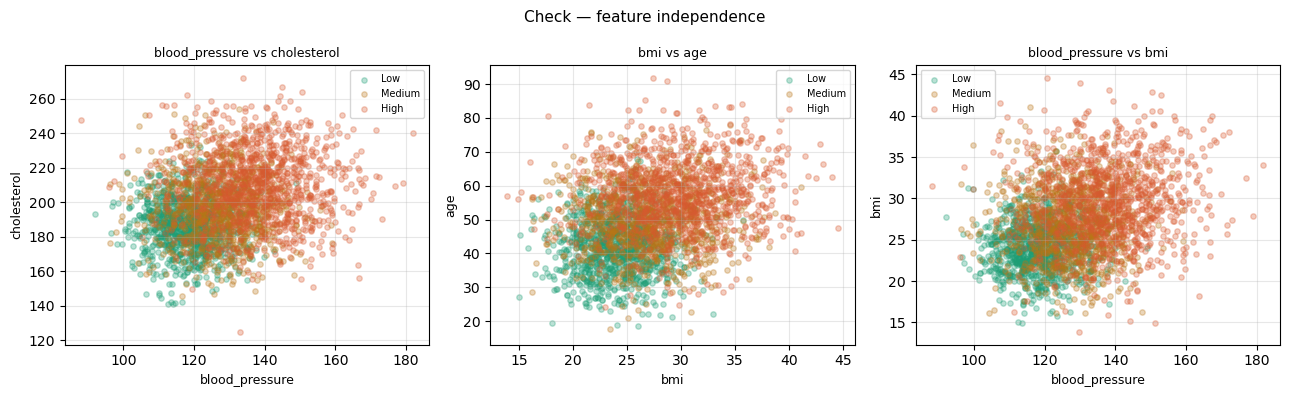

In [114]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle("Check — feature independence", fontsize=11)
# no pattern = good for GNB

pairs = [('blood_pressure', 'cholesterol'),
         ('bmi', 'age'),
         ('blood_pressure', 'bmi')]

for ax, (f1, f2) in zip(axes, pairs):
    i1 = feature_names.index(f1)
    i2 = feature_names.index(f2)
    for cls in [0, 1, 2]:
        mask = y == cls
        ax.scatter(X_final[mask, i1], X_final[mask, i2],
                   color=colors[cls], alpha=0.3, s=15,
                   label=class_labels[cls])
    ax.set_xlabel(f1, fontsize=9)
    ax.set_ylabel(f2, fontsize=9)
    ax.set_title(f"{f1} vs {f2}", fontsize=9)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [115]:
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, random_state=42, stratify=y
)

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

In [117]:
gnb = GaussianNB()
gnb.fit(X_train_sc, y_train)

y_pred = gnb.predict(X_test_sc)
y_prob = gnb.predict_proba(X_test_sc)

print(f"GNB Accuracy: {accuracy_score(y_test, y_pred):.4f}")

GNB Accuracy: 0.7183


In [118]:
# GNB stores theta_ (means) and var_ (variances) — no covariance, just variance

print("Per-class means (scaled):")
means_df = pd.DataFrame(
    gnb.theta_,
    index=['Low', 'Medium', 'High'],
    columns=feature_names
).round(3)
print(means_df)

print("\nPer-class variances (scaled):")
var_df = pd.DataFrame(
    gnb.var_,
    index=['Low', 'Medium', 'High'],
    columns=feature_names
).round(3)
print(var_df)

Per-class means (scaled):
        blood_pressure  cholesterol    bmi    age
Low             -0.740       -0.572 -0.618 -0.716
Medium          -0.029       -0.027 -0.025  0.012
High             0.769        0.599  0.644  0.705

Per-class variances (scaled):
        blood_pressure  cholesterol    bmi    age
Low              0.337        0.519  0.395  0.529
Medium           0.540        0.741  0.752  0.689
High             0.983        1.053  1.056  0.773


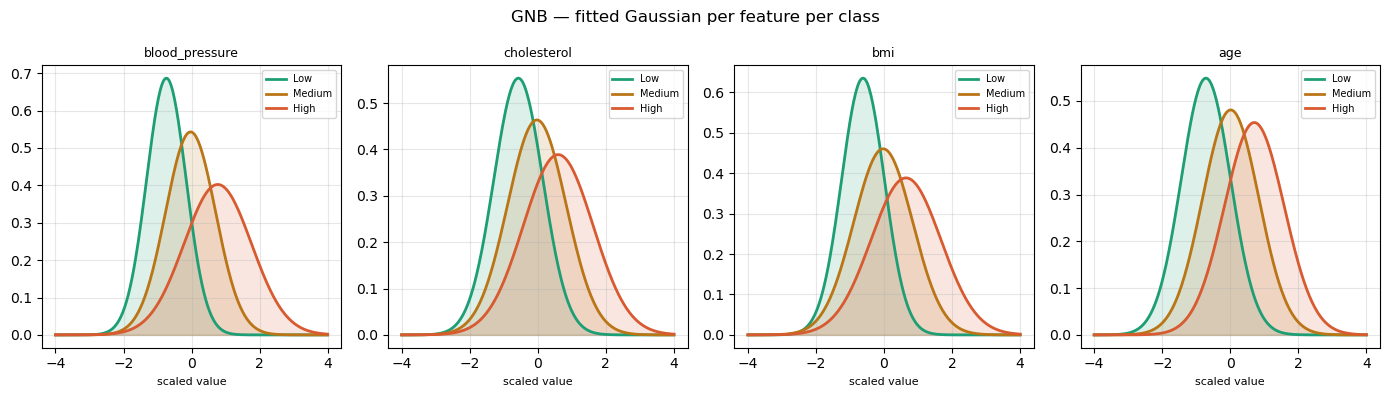

In [119]:
# per-feature Gaussian curves GNB fitted
# GNB models each feature as a separate bell curve per class

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
fig.suptitle("GNB — fitted Gaussian per feature per class", fontsize=12)

x_range = np.linspace(-4, 4, 300)

for j, feat in enumerate(feature_names):
    ax = axes[j]
    for cls in [0, 1, 2]:
        mean = gnb.theta_[cls, j]
        std  = np.sqrt(gnb.var_[cls, j])
        # gaussian curve: (1/std*sqrt(2pi)) * exp(-0.5*((x-mean)/std)^2)
        curve = (1 / (std * np.sqrt(2 * np.pi))) * \
                np.exp(-0.5 * ((x_range - mean) / std) ** 2)
        ax.plot(x_range, curve, color=colors[cls],
                linewidth=2, label=class_labels[cls])
        ax.fill_between(x_range, curve, alpha=0.15, color=colors[cls])
    ax.set_title(feat, fontsize=9)
    ax.set_xlabel("scaled value", fontsize=8)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [122]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis()
lda.fit(X_train_sc, y_train)

y_pred_lda = lda.predict(X_test_sc)

print(f"GNB Accuracy: {accuracy_score(y_test, y_pred):.4f}")

GNB Accuracy: 0.7183


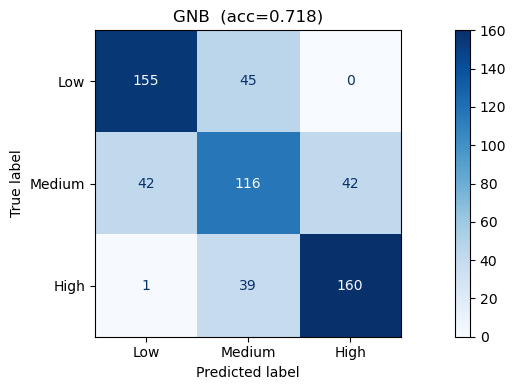

In [123]:
fig, ax = plt.subplots(figsize=(11, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Low', 'Medium', 'High'],
    cmap='Blues', ax=ax
)
ax.set_title(f"GNB  (acc={accuracy_score(y_test, y_pred):.3f})")

plt.tight_layout()
plt.show()